<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/08_pytorch_paper_replicating_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08. PyTorch Paper Replicating Exercises

Welcome to the 08. PyTorch Paper Replicating exercises.

Your objective is to write code to satisify each of the exercises below.

Some starter code has been provided to make sure you have all the resources you need.

> **Note:** There may be more than one solution to each of the exercises.

## Resources

1. These exercises/solutions are based on [section 08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/tjpW_BY8y3g) (but try the exercises yourself first!).
3. See [all solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/). 

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")


[INFO] torch/torchvision versions not as required, installing nightly versions.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/nightly/cu113
torch version: 2.6.0+cu118
torchvision version: 0.21.0+cu118


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

/home/administrator/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get data

Want to download the data we've been using in PyTorch Paper Replicating: https://www.learnpytorch.io/08_pytorch_paper_replicating/#1-get-data

In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [6]:
# Create image size (from Table 3 in the ViT paper) 
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])           
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7f414b654550>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

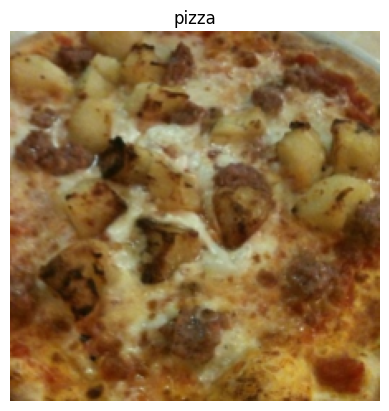

In [9]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## 1. Replicate the ViT architecture we created with in-built [PyTorch transformer layers](https://pytorch.org/docs/stable/nn.html#transformer-layers).

* You'll want to look into replacing our `TransformerEncoderBlock()` class with [`torch.nn.TransformerEncoderLayer()`](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html#torch.nn.TransformerEncoderLayer) (these contain the same layers as our custom blocks). 
* You can stack `torch.nn.TransformerEncoderLayer()`'s on top of each other with [`torch.nn.TransformerEncoder()`](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html#torch.nn.TransformerEncoder).

### 1. Patch embedding layer.

In [10]:
rand_image_tensor = torch.randn(32, 3, 224, 224)
rand_image_tensor.shape

torch.Size([32, 3, 224, 224])

In [11]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels:int=3, patch_size:int=16, embedding_dimension:int=768):
        super().__init__()
        self.patch_size = patch_size
        self.patcher = nn.Conv2d(in_channels=in_channels, out_channels=embedding_dimension, kernel_size=patch_size, stride=patch_size, padding=0)
        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, f'Image size: {image_resolution} is not divisible by Patch size: {self.patch_size}.'
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        return x_flattened.permute(0, 2, 1)

In [12]:
patch_embedding = PatchEmbedding()
patch_embedding_output = patch_embedding(rand_image_tensor)
print(f'Input shape: {rand_image_tensor.shape}, Output shape: {patch_embedding_output.shape}.')

Input shape: torch.Size([32, 3, 224, 224]), Output shape: torch.Size([32, 196, 768]).


### 2. Tranformer encoder layer.

In [13]:
transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, nhead=12, dim_feedforward=3072, dropout=0.1, activation='gelu', batch_first=True, norm_first=True)
summary(model=transformer_encoder_layer, input_size=patch_embedding_output.shape)

Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoderLayer                  [32, 196, 768]            --
├─LayerNorm: 1-1                         [32, 196, 768]            1,536
├─MultiheadAttention: 1-2                [32, 196, 768]            2,362,368
├─Dropout: 1-3                           [32, 196, 768]            --
├─LayerNorm: 1-4                         [32, 196, 768]            1,536
├─Linear: 1-5                            [32, 196, 3072]           2,362,368
├─Dropout: 1-6                           [32, 196, 3072]           --
├─Linear: 1-7                            [32, 196, 768]            2,360,064
├─Dropout: 1-8                           [32, 196, 768]            --
Total params: 7,087,872
Trainable params: 7,087,872
Non-trainable params: 0
Total mult-adds (M): 151.22
Input size (MB): 19.27
Forward/backward pass size (MB): 269.75
Params size (MB): 18.90
Estimated Total Size (MB): 307.92

### 3. Transformer encoder.

In [14]:
transformer_encoder = nn.TransformerEncoder(encoder_layer=transformer_encoder_layer, num_layers=12)
summary(model=transformer_encoder, input_size=patch_embedding_output.shape)

/home/administrator/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
TransformerEncoder                       [32, 196, 768]            --
├─ModuleList: 1-1                        --                        --
│    └─TransformerEncoderLayer: 2-1      [32, 196, 768]            --
│    │    └─LayerNorm: 3-1               [32, 196, 768]            1,536
│    │    └─MultiheadAttention: 3-2      [32, 196, 768]            2,362,368
│    │    └─Dropout: 3-3                 [32, 196, 768]            --
│    │    └─LayerNorm: 3-4               [32, 196, 768]            1,536
│    │    └─Linear: 3-5                  [32, 196, 3072]           2,362,368
│    │    └─Dropout: 3-6                 [32, 196, 3072]           --
│    │    └─Linear: 3-7                  [32, 196, 768]            2,360,064
│    │    └─Dropout: 3-8                 [32, 196, 768]            --
│    └─TransformerEncoderLayer: 2-2      [32, 196, 768]            --
│    │    └─LayerNorm: 3-9               [32, 196, 768]   

### 4. VIT model.

In [15]:
import torch 
from torch import nn

class VIT(nn.Module):
    def __init__(self, img_size:int=224, num_channels:int=3, patch_size:int=16, embedding_dim:int=768, dropout:float=0.1, mlp_size:int=3072, num_transformer_layers:int=12, num_heads:int=12, num_classes:int=1000):
        super().__init__()
        assert img_size % patch_size == 0, f'Image size: {img_size} must be divisible by Patch size: {patch_size}.'
        self.patch_embedding = PatchEmbedding(in_channels=num_channels, patch_size=patch_size, embedding_dimension=embedding_dim)
        self.class_token = nn.Parameter(data=torch.randn(size=(1, 1, embedding_dim)), requires_grad=True)
        num_patches = (img_size**2) // (patch_size**2)
        self.positional_embedding = nn.Parameter(data=torch.randn(size=(1, num_patches+1, embedding_dim)))
        self.embedding_dropout = nn.Dropout(p=dropout)
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim, nhead=num_heads, dim_feedforward=mlp_size, activation='gelu', batch_first=True, norm_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer=self.transformer_encoder_layer, num_layers=num_transformer_layers)
        self.mlp_head = nn.Sequential(nn.LayerNorm(normalized_shape=embedding_dim), nn.Linear(in_features=embedding_dim, out_features=num_classes))
        
    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embedding(x)
        class_token = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat(tensors=(class_token, x), dim=1)
        x = self.positional_embedding + x
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        x = self.mlp_head(x[:, 0])
        return x

In [16]:
demo_img = torch.randn(1, 3, 224, 224).to(device)
vit  = VIT(num_classes=len(class_names)).to(device)
summary(model=vit, input_size=demo_img.shape)

Layer (type:depth-idx)                        Output Shape              Param #
VIT                                           [1, 3]                    7,239,936
├─PatchEmbedding: 1-1                         [1, 196, 768]             --
│    └─Conv2d: 2-1                            [1, 768, 14, 14]          590,592
│    └─Flatten: 2-2                           [1, 768, 196]             --
├─Dropout: 1-2                                [1, 197, 768]             --
├─TransformerEncoder: 1-3                     [1, 197, 768]             --
│    └─ModuleList: 2-3                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-2      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-3      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-4      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-5      [1, 197, 

## 2. Turn the custom ViT architecture we created into a Python script, for example, `vit.py`.

* You should be able to import an entire ViT model using something like`from vit import ViT`.
* We covered the art of turning code cells into Python scrips in [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/). 


In [17]:
%%writefile vit.py

import torch
from torch import nn

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels:int=3, patch_size:int=16, embedding_dimension:int=768):
        super().__init__()
        self.patch_size = patch_size
        self.patcher = nn.Conv2d(in_channels=in_channels, out_channels=embedding_dimension, kernel_size=patch_size, stride=patch_size, padding=0)
        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        
    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, f'Image size: {image_resolution} is not divisible by Patch size: {self.patch_size}.'
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        return x_flattened.permute(0, 2, 1)
    
class VIT(nn.Module):
    def __init__(self, img_size:int=224, num_channels:int=3, patch_size:int=16, embedding_dim:int=768, dropout:float=0.1, mlp_size:int=3072, num_transformer_layers:int=12, num_heads:int=12, num_classes:int=1000):
        super().__init__()
        assert img_size % patch_size == 0, f'Image size: {img_size} must be divisible by Patch size: {patch_size}.'
        self.patch_embedding = PatchEmbedding(in_channels=num_channels, patch_size=patch_size, embedding_dimension=embedding_dim)
        self.class_token = nn.Parameter(data=torch.randn(size=(1, 1, embedding_dim)), requires_grad=True)
        num_patches = (img_size**2) // (patch_size**2)
        self.positional_embedding = nn.Parameter(data=torch.randn(size=(1, num_patches+1, embedding_dim)))
        self.embedding_dropout = nn.Dropout(p=dropout)
        self.transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim, nhead=num_heads, dim_feedforward=mlp_size, activation='gelu', batch_first=True, norm_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer=self.transformer_encoder_layer, num_layers=num_transformer_layers)
        self.mlp_head = nn.Sequential(nn.LayerNorm(normalized_shape=embedding_dim), nn.Linear(in_features=embedding_dim, out_features=num_classes))
        
    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embedding(x)
        class_token = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat(tensors=(class_token, x), dim=1)
        x = self.positional_embedding + x
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        x = self.mlp_head(x[:, 0])
        return x

Overwriting vit.py


In [18]:
!python3 vit.py

In [19]:
from vit import VIT
import torch
from torch import nn

imported_vit = VIT()
summary(model=vit, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
VIT                                           [1, 3]                    7,239,936
├─PatchEmbedding: 1-1                         [1, 196, 768]             --
│    └─Conv2d: 2-1                            [1, 768, 14, 14]          590,592
│    └─Flatten: 2-2                           [1, 768, 196]             --
├─Dropout: 1-2                                [1, 197, 768]             --
├─TransformerEncoder: 1-3                     [1, 197, 768]             --
│    └─ModuleList: 2-3                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-2      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-3      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-4      [1, 197, 768]             7,087,872
│    │    └─TransformerEncoderLayer: 3-5      [1, 197, 

## 3. Pretrained VIT model.

### 1. Train a pretrained ViT feature extractor model (like the one we made in [08. PyTorch Paper Replicating section 10](https://www.learnpytorch.io/08_pytorch_paper_replicating/#10-bring-in-pretrained-vit-from-torchvisionmodels-on-same-dataset)) on 20% of the pizza, steak and sushi data like the dataset we used in [07. PyTorch Experiment Tracking section 7.3](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#73-download-different-datasets) 
* See how it performs compared to the EffNetB2 model we compared it to in [08. PyTorch Paper Replicating section 10.6](https://www.learnpytorch.io/08_pytorch_paper_replicating/#106-save-feature-extractor-vit-model-and-check-file-size).

In [20]:
set_seeds()
vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_vit = torchvision.models.vit_b_16(weights=vit_weights)
for param in pretrained_vit.parameters():
    param.requires_grad = False
embedded_dim = 768
pretrained_vit.heads = nn.Sequential(nn.LayerNorm(normalized_shape=embedded_dim), nn.Linear(in_features=embedded_dim, out_features=len(class_names)))
summary(model=pretrained_vit, input_size=(1, 3, 224, 224), col_names=['input_size', 'output_size', 'num_params', 'trainable'], col_width=20, row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [21]:
data_20_percent_path = download_data(source='https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip', destination='pizza_steak_sushi_20_percent')
train_dir_20_percent = data_20_percent_path / 'train'
vit_transforms = vit_weights.transforms()
train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent, test_dir=test_dir, transform=vit_transforms, batch_size=32)

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


### 2. Try repeating the steps from excercise 3 but this time use the "`ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1`" pretrained weights from [`torchvision.models.vit_b_16()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16).
* Note: ViT pretrained with SWAG weights has a minimum input image size of (384, 384), though this is accessible in the weights `.transforms()` method.

In [22]:
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(params=pretrained_vit.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss();
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit, train_dataloader=train_dataloader_20_percent, test_dataloader=test_dataloader, optimizer=optimizer, loss_fn=loss_fn, epochs=10, device=device)

 10%|█         | 1/10 [00:17<02:38, 17.66s/it]

Epoch: 1 | train_loss: 0.5827 | train_acc: 0.8208 | test_loss: 0.2192 | test_acc: 0.8873


 20%|██        | 2/10 [00:35<02:21, 17.65s/it]

Epoch: 2 | train_loss: 0.1982 | train_acc: 0.9229 | test_loss: 0.2058 | test_acc: 0.9280


 30%|███       | 3/10 [00:53<02:04, 17.72s/it]

...

Epoch: 8 | train_loss: 0.0592 | train_acc: 0.9896 | test_loss: 0.1898 | test_acc: 0.9280


 90%|█████████ | 9/10 [02:40<00:17, 17.95s/it]

Epoch: 9 | train_loss: 0.0622 | train_acc: 0.9917 | test_loss: 0.1962 | test_acc: 0.9384


100%|██████████| 10/10 [02:58<00:00, 17.88s/it]

Epoch: 10 | train_loss: 0.0400 | train_acc: 0.9938 | test_loss: 0.1841 | test_acc: 0.9583


### 3. Most wrong examples.

In [23]:
from tqdm.auto import tqdm
from pathlib import Path
from PIL import Image

test_data_paths = list(Path(test_dir).glob('*/*.jpg'))
test_labels = [path.parent.stem for path in test_data_paths]

def pred_and_store(test_paths, model, transform, class_names, device):
    test_pred_list = []
    for path in tqdm(test_paths):
        pred_dict = {}
        pred_dict['image_path'] = path
        class_name = path.parent.stem
        pred_dict['class_name'] = class_name
        img = Image.open(path)
        transformed_image = transform(img).unsqueeze(0)
        model.eval()
        with torch.inference_mode():
            pred_logits = model(transformed_image.to(device))  
            pred_probs = torch.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_probs, dim=1)
            pred_class = class_names[pred_label.cpu()]
            pred_dict['pred_probs'] = pred_probs.unsqueeze(0).max().cpu().item()
            pred_dict['pred_class'] = pred_class
        pred_dict['correct'] = class_name == pred_class
        test_pred_list.append(pred_dict)
    return test_pred_list

test_pred_dicts = pred_and_store(test_paths=test_data_paths, model=pretrained_vit, transform=vit_transforms, class_names=class_names, device=device)
test_pred_dicts[:5]

100%|██████████| 75/75 [00:02<00:00, 26.33it/s]


[{'image_path': PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
  'class_name': 'pizza',
  'pred_probs': 0.9998794794082642,
  'pred_class': 'pizza',
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
  'class_name': 'pizza',
  'pred_probs': 0.9999614953994751,
  'pred_class': 'pizza',
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
  'class_name': 'pizza',
  'pred_probs': 0.9998496770858765,
  'pred_class': 'pizza',
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi/test/pizza/398345.jpg'),
  'class_name': 'pizza',
  'pred_probs': 0.9998887777328491,
  'pred_class': 'pizza',
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
  'class_name': 'pizza',
  'pred_probs': 0.9998075366020203,
  'pred_class': 'pizza',
  'correct': True}]

# 4. Our custom ViT model architecture closely mimics that of the ViT paper, however, our training recipe misses a few things. 
* Research some of the following topics from Table 3 in the ViT paper that we miss and write a sentence about each and how it might help with training:
    * **ImageNet-21k pretraining** 
    * **Learning rate warmup** 
    * **Learning rate decay** 
    * **Gradient clipping** 

In [ ]:
# TODO: your explanations of the above terms